# SVM v2 — Baseline SVM + All Scenarios (S1-S8)

In [3]:
# Cell 1: Import
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.metrics import accuracy_score

from config import RANDOM_SEED, MODELS_DIR
from src.experiment_runner import (
    get_splits, load_and_norm, split_cal_test,
    run_zero_shot, run_calibration, print_comparison,
    TEST_SUBJECTS, TRAIN_SUBJECTS, META,
)
from src.feature_extraction import extract_features_batch
from src.evaluation import measure_latency, print_latency

splits = get_splits()
print(f'Train subjects: {TRAIN_SUBJECTS}')
print(f'Test subjects:  {TEST_SUBJECTS}')

Train subjects: ['h0', 'h1', 'h10', 'h11', 'h12', 'h13', 'h14', 'h15', 'h18', 'h19', 'h2', 'h20', 'h21', 'h23', 'h25', 'h26', 'h27', 'h28', 'h29', 'h4', 'h5', 'h6', 'h8', 'h9']
Test subjects:  ['h7', 'h22', 'h3', 'h24', 'h16', 'h17']


In [4]:
# Cell 2: Load or train SVM
MODEL_PATH = MODELS_DIR / 'svm_v2.pkl'

train_combined = pd.concat([splits['train_df'], splits['s5_train']])
X_train, y_train, norm_stats = load_and_norm(train_combined, verbose=True)
print(f'Train: {X_train.shape}')

if MODEL_PATH.exists():
    saved = joblib.load(MODEL_PATH)
    svm, scaler = saved['model'], saved['scaler']
    print(f'Loaded from {MODEL_PATH}')
else:
    print('Extracting features...')
    F_train = extract_features_batch(X_train)
    MAX_SVM = 50000
    idx = resample(np.arange(len(y_train)), n_samples=MAX_SVM,
                   random_state=RANDOM_SEED, stratify=y_train)
    F_sub, y_sub = F_train[idx], y_train[idx]
    print(f'Subsampled to {MAX_SVM}')
    scaler = StandardScaler().fit(F_sub)
    print('Training SVM...')
    svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=RANDOM_SEED)
    svm.fit(scaler.transform(F_sub), y_sub)
    joblib.dump({'model': svm, 'scaler': scaler}, MODEL_PATH)
    print(f'Saved to {MODEL_PATH}')

Loading windows: 100%|██████████| 9021/9021 [00:03<00:00, 2718.85it/s]


Train: (1030712, 8, 50)
Extracting features...
Subsampled to 50000
Training SVM...
Saved to /Users/erdiantiwigaputriandini/Documents/Kuliah/Tugas Akhir/04. TA/02. Code/Tugas-Akhir/results/models/svm_v2.pkl


In [5]:
# Cell 3: Predict and finetune functions
def svm_predict(X):
    return svm.predict(scaler.transform(extract_features_batch(X)))

def svm_finetune(X_cal, y_cal):
    F_cal = scaler.transform(extract_features_batch(X_cal))
    svm_ft = SVC(kernel='rbf', C=10, gamma='scale', random_state=RANDOM_SEED)
    svm_ft.fit(F_cal, y_cal)
    def predict_ft(X):
        return svm_ft.predict(scaler.transform(extract_features_batch(X)))
    return predict_ft

In [6]:
# Cell 4: S1-S5 Zero-shot
print('Option B -- Zero-shot:')
zero_results = run_zero_shot(svm_predict, splits, norm_stats)

Option B -- Zero-shot:
  S1 zero-shot: 0.4624
  S2 zero-shot: 0.3915
  S3 zero-shot: 0.3979
  S4 zero-shot: 0.4759
  S5 zero-shot: 0.5326


In [7]:
# Cell 5: S1-S5 Calibrated
print('Option A -- Calibration:')
cal_results = run_calibration(svm_predict, svm_finetune, splits, norm_stats)

Option A -- Calibration:
  S1 calibrated: 0.6228
  S2 calibrated: 0.6296
  S3 calibrated: 0.5817
  S4 calibrated: 0.6666
  S5 calibrated: 0.7404


In [8]:
# Cell 6: S1-S5 Results
print_comparison(zero_results, cal_results, name='SVM (v2)')


  SVM (v2) — RESULTS
Scenario        Zero-shot   Calibrated        Δ
-------------------------------------------------------
S1                46.24%       62.28%   +16.04%
S2                39.15%       62.96%   +23.81%
S3                39.79%       58.17%   +18.38%
S4                47.59%       66.66%   +19.06%
S5                53.26%       74.04%   +20.78%


In [9]:
# Cell 7: S6 Combined Factor (Cross-Subject + Electrode Shift)
print('\n=== S6: Combined Factor (Cross-Subject + Shift) ===')
print('Test: test subjects, session 0, shifted positions (p1-p10)')
print('This combines cross-subject AND electrode shift simultaneously.\n')

s6_test = META[(META['subject'].isin(TEST_SUBJECTS)) & (META['session']==0) & (META['position']>0)]

# Zero-shot
X_s6, y_s6, _ = load_and_norm(s6_test, stats=norm_stats)
s6_zs = accuracy_score(y_s6, svm_predict(X_s6))
print(f'S6 zero-shot (overall): {s6_zs:.4f}')

# Per-subject breakdown
print('\nPer-subject breakdown:')
s6_per_subj = {}
for subj in TEST_SUBJECTS:
    sdf = s6_test[s6_test['subject']==subj]
    if len(sdf)==0: continue
    X_s, y_s, _ = load_and_norm(sdf, stats=norm_stats)
    s6_per_subj[subj] = accuracy_score(y_s, svm_predict(X_s))
    print(f'  {subj}: {s6_per_subj[subj]:.4f}')

# Calibrated
print('\nCalibrated (per-subject):')
s6_cal_accs = []
for subj in TEST_SUBJECTS:
    sdf = s6_test[s6_test['subject']==subj]
    if len(sdf)==0: continue
    cal_df = sdf[sdf['repetition'].isin([0,1])]
    test_df = sdf[sdf['repetition']==2]
    if len(cal_df)==0 or len(test_df)==0: continue
    X_c, y_c, _ = load_and_norm(cal_df, stats=norm_stats)
    X_t, y_t, _ = load_and_norm(test_df, stats=norm_stats)
    ft = svm_finetune(X_c, y_c)
    acc = accuracy_score(y_t, ft(X_t))
    s6_cal_accs.append(acc)
    print(f'  {subj}: {acc:.4f}')
s6_cal = np.mean(s6_cal_accs)
print(f'\nS6 calibrated avg: {s6_cal:.4f}')


=== S6: Combined Factor (Cross-Subject + Shift) ===
Test: test subjects, session 0, shifted positions (p1-p10)
This combines cross-subject AND electrode shift simultaneously.

S6 zero-shot (overall): 0.3915

Per-subject breakdown:
  h7: 0.4044
  h22: 0.4716
  h3: 0.4125
  h24: 0.3490
  h16: 0.3730
  h17: 0.3275

Calibrated (per-subject):
  h7: 0.6481
  h22: 0.6661
  h3: 0.6163
  h24: 0.7593
  h16: 0.6587
  h17: 0.6665

S6 calibrated avg: 0.6691



=== S7: Gradual Electrode Shift Analysis (h24-h29) ===
Small-angle rotation subjects. Evaluate tolerance threshold.

Train subjects: ['h25', 'h26', 'h27', 'h28', 'h29']
Test subjects:  ['h24']
  Position  0: 0.4468
  Position  1: 0.4653
  Position  2: 0.4593
  Position  3: 0.4377
  Position  4: 0.4333
  Position  5: 0.4420
  Position  6: 0.4639
  Position  7: 0.4458
  Position  8: 0.4223
  Position  9: 0.4053
  Position 10: 0.3970

P0 (baseline): 0.4468
Average shifted (p1-p10): 0.4372


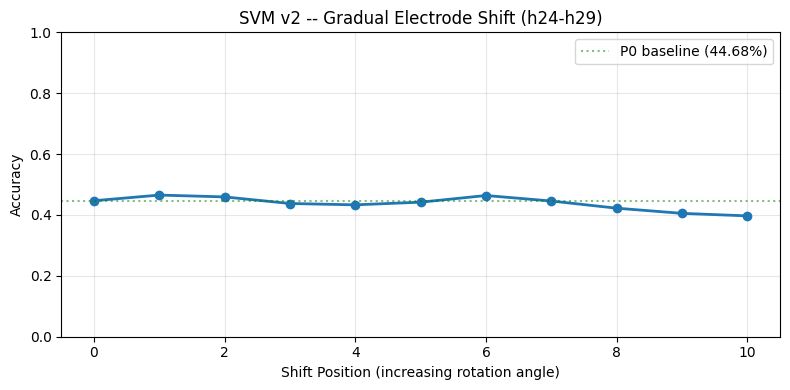

In [10]:
# Cell 8: S7 Gradual Electrode Shift (h24-h29)
print('\n=== S7: Gradual Electrode Shift Analysis (h24-h29) ===')
print('Small-angle rotation subjects. Evaluate tolerance threshold.\n')

shift_subjects = [f'h{i}' for i in range(24, 30)]
shift_in_train = [s for s in shift_subjects if s in TRAIN_SUBJECTS]
shift_in_test = [s for s in shift_subjects if s in TEST_SUBJECTS]
print(f'Train subjects: {shift_in_train}')
print(f'Test subjects:  {shift_in_test}')

shift_data = META[(META['subject'].isin(shift_subjects)) & (META['session']==0)]

# Per-position accuracy
s7_acc = {}
for pos in sorted(shift_data['position'].unique()):
    pos_df = shift_data[shift_data['position']==pos]
    X_p, y_p, _ = load_and_norm(pos_df, stats=norm_stats)
    s7_acc[pos] = accuracy_score(y_p, svm_predict(X_p))
    print(f'  Position {pos:2d}: {s7_acc[pos]:.4f}')

print(f'\nP0 (baseline): {s7_acc.get(0, 0):.4f}')
print(f'Average shifted (p1-p10): {np.mean([s7_acc[p] for p in s7_acc if p>0]):.4f}')

plt.figure(figsize=(8, 4))
plt.plot(list(s7_acc.keys()), list(s7_acc.values()), 'o-', linewidth=2)
plt.axhline(y=s7_acc.get(0, 0), color='green', ls=':', alpha=0.5, label=f'P0 baseline ({s7_acc.get(0,0):.2%})')
plt.xlabel('Shift Position (increasing rotation angle)')
plt.ylabel('Accuracy')
plt.title('SVM v2 -- Gradual Electrode Shift (h24-h29)')
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


=== S8: Few-Shot Calibration Analysis ===
How much calibration data is needed?

  Zero-shot           : 0.3962  (~0 trials)
  1 rep, p0 only      : 0.2591  (~7 trials)
  1 rep, all pos      : 0.5787  (~77 trials)
  2 rep, p0 only      : 0.2849  (~14 trials)
  2 rep, all pos      : 0.6630  (~154 trials)


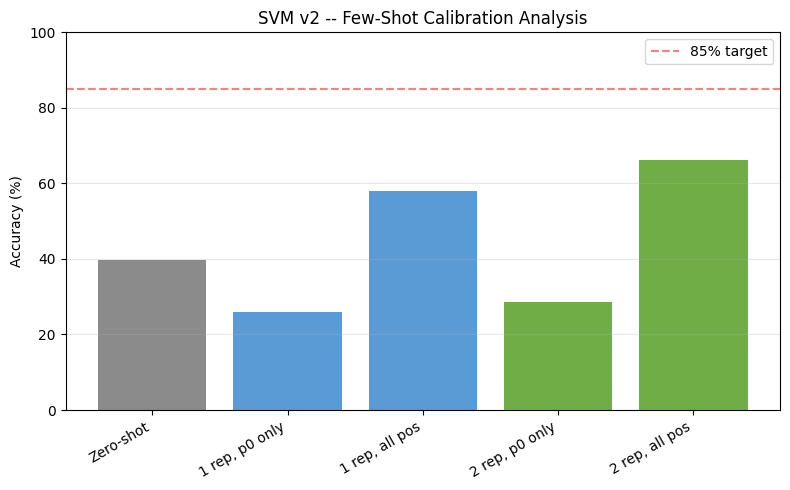

In [11]:
# Cell 9: S8 Few-Shot Calibration Analysis
print('\n=== S8: Few-Shot Calibration Analysis ===')
print('How much calibration data is needed?\n')

subset_s8 = META[(META['session']==0) & (META['subject'].isin(TEST_SUBJECTS))]

configs = [
    ('Zero-shot',        [],     False),
    ('1 rep, p0 only',   [0],    True),
    ('1 rep, all pos',   [0],    False),
    ('2 rep, p0 only',   [0,1],  True),
    ('2 rep, all pos',   [0,1],  False),
]

s8_results = {}
for label, reps, p0_only in configs:
    accs = []
    for subj in TEST_SUBJECTS:
        sdf = subset_s8[subset_s8['subject']==subj]
        if len(reps)==0:
            X_t, y_t, _ = load_and_norm(sdf, stats=norm_stats)
            accs.append(accuracy_score(y_t, svm_predict(X_t)))
            continue
        if p0_only:
            cal_df = sdf[(sdf['repetition'].isin(reps)) & (sdf['position']==0)]
        else:
            cal_df = sdf[sdf['repetition'].isin(reps)]
        test_df = sdf[sdf['repetition']==2]
        if len(cal_df)==0 or len(test_df)==0: continue
        X_c, y_c, _ = load_and_norm(cal_df, stats=norm_stats)
        X_t, y_t, _ = load_and_norm(test_df, stats=norm_stats)
        ft = svm_finetune(X_c, y_c)
        accs.append(accuracy_score(y_t, ft(X_t)))
    s8_results[label] = np.mean(accs)
    n_trials = 0 if len(reps)==0 else (7*len(reps) if p0_only else 77*len(reps))
    print(f'  {label:<20s}: {s8_results[label]:.4f}  (~{n_trials} trials)')

plt.figure(figsize=(8, 5))
labels = list(s8_results.keys())
vals = [v*100 for v in s8_results.values()]
colors = ['#8B8B8B'] + ['#5B9BD5']*2 + ['#70AD47']*2
plt.bar(range(len(labels)), vals, color=colors)
plt.axhline(y=85, color='red', ls='--', alpha=0.5, label='85% target')
plt.xticks(range(len(labels)), labels, rotation=30, ha='right')
plt.ylabel('Accuracy (%)')
plt.title('SVM v2 -- Few-Shot Calibration Analysis')
plt.ylim(0, 100)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# Cell 10: Latency
def svm_single(x):
    return svm.predict(scaler.transform(extract_features_batch(x)))
latency = measure_latency(svm_single, X_train[:1], n_runs=500)
print_latency(latency, 'SVM v2')


Latency — SVM v2
  Mean:   3.65 ms
  Median: 3.57 ms
  P95:    4.02 ms
  <300ms: ✓


In [13]:
# Cell 11: Full Summary
print('\n' + '='*60)
print('  SVM v2 -- FULL RESULTS')
print('='*60)
print(f'{"Scenario":<25} {"Zero-shot":>12} {"Calibrated":>12}')
print('-'*60)
for s in ['S1','S2','S3','S4','S5']:
    print(f'{s:<25} {zero_results[s]*100:>10.2f}%  {cal_results[s]*100:>10.2f}%')
print(f'{"S6 Combined":<25} {s6_zs*100:>10.2f}%  {s6_cal*100:>10.2f}%')
print(f'{"S7 Gradual (avg p1-10)":<25} {np.mean([s7_acc[p] for p in s7_acc if p>0])*100:>10.2f}%  {"--":>12}')
for label, val in s8_results.items():
    if label == 'Zero-shot': continue
    print(f'{"S8 " + label:<25} {"--":>12}  {val*100:>10.2f}%')
print(f'{"Latency p95 (ms)":<25} {latency["p95_ms"]:>10.2f}')
print('='*60)


  SVM v2 -- FULL RESULTS
Scenario                     Zero-shot   Calibrated
------------------------------------------------------------
S1                             46.24%       62.28%
S2                             39.15%       62.96%
S3                             39.79%       58.17%
S4                             47.59%       66.66%
S5                             53.26%       74.04%
S6 Combined                    39.15%       66.91%
S7 Gradual (avg p1-10)         43.72%            --
S8 1 rep, p0 only                   --       25.91%
S8 1 rep, all pos                   --       57.87%
S8 2 rep, p0 only                   --       28.49%
S8 2 rep, all pos                   --       66.30%
Latency p95 (ms)                4.02
